## Imports

In [38]:
import pandas as pd
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from sklearn.tree import export_text

#### Load and check data

In [85]:
# Load the training and test data
X_train = pd.read_csv('Datasets/cleaned_X_train2.csv')
X_test = pd.read_csv('Datasets/cleaned_X_test2.csv')
y_train = pd.read_csv('Datasets/y_train.csv')
y_test = pd.read_csv('Datasets/y_test.csv')


In [86]:
# Ensure the test data has the same columns as the training data
X_test = X_test[X_train.columns]
y_test = y_test[y_train.columns] 

In [87]:
# check the shape of the data
print("Shape of X_train:", X_train.shape)
print("Shape of y_train:", y_train.shape)
print("Shape of y_test:", y_test.shape)

# check collumn names are identical
print("X_train columns:", X_train.columns.tolist())
print("X_test columns:", X_test.columns.tolist())


y_train = y_train.values.squeeze()  # Flatten if a single column DataFrame
y_test = y_test.values.squeeze()


Shape of X_train: (404, 516)
Shape of y_train: (404, 10)
Shape of y_test: (101, 10)
X_train columns: ['James Sheldon', 'Corey Allen', 'Barbara Barrie', 'Joan Blondell', 'John DiMaggio', 'Cloris Leachman', 'David Carson', 'Chet Richards', 'Deborah McIntyre', 'Ted Roberts', 'Cirroc Lofton', 'Robert Legato', 'Michael Ray Rhodes', 'Russell Johnson', 'Robert Iscove', 'Bret Haaland', 'Jack Albertson', 'Harlan Ellison', 'Howard McNear', 'Richard De Roy', 'Jean Lisette Aroeste', 'Carey Wilber', 'Bill Reed', 'George Grizzard', 'Leonard Mlodinow', 'Robert Butler', 'Inger Stevens', 'John Larch', 'Marc Daniels', 'Russ Mayberry', 'J. Pat O&apos;Malley', 'Jack Klugman', 'Luther Adler', 'David White', 'Paul W. Fairman', 'Gilbert Ralston', 'Tracy Tormé', 'James Daly', 'Evan Gore', 'Edithe Swensen', 'John Whelpley', 'John Billingsley', 'Patricia Barry', 'John Marley', 'Charles Beaumont', 'Margie Liszt', 'Margaret Field', 'Lamont Johnson', 'Ira Steven Behr', 'Shirley Ballard', 'Hans Beimler', 'Timothy B

In [88]:
# check if there are missing values or collumns
train_columns = set(X_train.columns)
test_columns = set(X_test.columns)

missing_in_test = train_columns - test_columns
extra_in_test = test_columns - train_columns

print("Missing in X_test:", missing_in_test)
print("Extra in X_test:", extra_in_test)


Missing in X_test: set()
Extra in X_test: set()


## Initialize and train the decision tree

**Hyperparameter Tuning**: Use techniques like grid search (GridSearchCV) or random search (RandomizedSearchCV) to find optimal parameters for your decision tree. 

**Overfitting Prevention**: Adjust parameters like max_depth, min_samples_split, and min_samples_leaf to prevent overfitting.


In [89]:
# Initialize the classifier
dt_classifier = DecisionTreeClassifier(criterion='entropy', max_depth=None, random_state=60) # choose entropy as the data set is smaller

# Train the classifier
dt_classifier.fit(X_train, y_train)


DecisionTreeClassifier(criterion='entropy', random_state=60)

## predict

In [90]:
# Predict on test data
y_pred = dt_classifier.predict(X_test)

In [91]:
print("Shape of y_test:", y_test.shape)
print("Shape of y_pred:", y_pred.shape)
assert y_test.shape == y_pred.shape, "Shapes of y_test and y_pred must match."


Shape of y_test: (101, 10)
Shape of y_pred: (101, 10)


## Evaluate model

In [96]:
# Calculate accuracy
accuracy = accuracy_score(y_test, y_pred)
print(f'Accuracy: {accuracy:.2f}')

# Classification Report
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.09
Classification Report:
               precision    recall  f1-score   support

           0       0.33      0.25      0.29         8
           1       0.07      0.09      0.08        11
           2       0.00      0.00      0.00        16
           3       0.26      0.33      0.29        15
           4       0.18      0.36      0.24        11
           5       0.10      0.14      0.12         7
           6       0.27      0.24      0.25        17
           7       0.17      0.17      0.17        12
           8       0.25      0.17      0.20        18
           9       0.15      0.18      0.17        11

   micro avg       0.18      0.19      0.18       126
   macro avg       0.18      0.19      0.18       126
weighted avg       0.18      0.19      0.18       126
 samples avg       0.18      0.19      0.18       126



## Visualize tree

In [93]:
tree_rules = export_text(dt_classifier, feature_names=list(X_train.columns))
print(tree_rules)


|--- year <= 1966.50
|   |--- title <= 0.00
|   |   |--- Shelley Fabares <= 0.50
|   |   |   |--- IMDb description <= 0.00
|   |   |   |   |--- Frank Overton <= 0.50
|   |   |   |   |   |--- class: 0
|   |   |   |   |--- Frank Overton >  0.50
|   |   |   |   |   |--- class: 0
|   |   |   |--- IMDb description >  0.00
|   |   |   |   |--- Lawrence Dobkin <= 0.50
|   |   |   |   |   |--- duration <= 0.36
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |--- duration >  0.36
|   |   |   |   |   |   |--- class: 0
|   |   |   |   |--- Lawrence Dobkin >  0.50
|   |   |   |   |   |--- class: 0
|   |   |--- Shelley Fabares >  0.50
|   |   |   |--- class: 1
|   |--- title >  0.00
|   |   |--- IMDb rating <= 0.74
|   |   |   |--- year <= 1962.50
|   |   |   |   |--- Douglas Heyes <= 0.50
|   |   |   |   |   |--- month <= 3.50
|   |   |   |   |   |   |--- title <= 0.00
|   |   |   |   |   |   |   |--- class: 0
|   |   |   |   |   |   |--- title >  0.00
|   |   |   |   |   |   |   |--- IM

Matplotlib is building the font cache; this may take a moment.


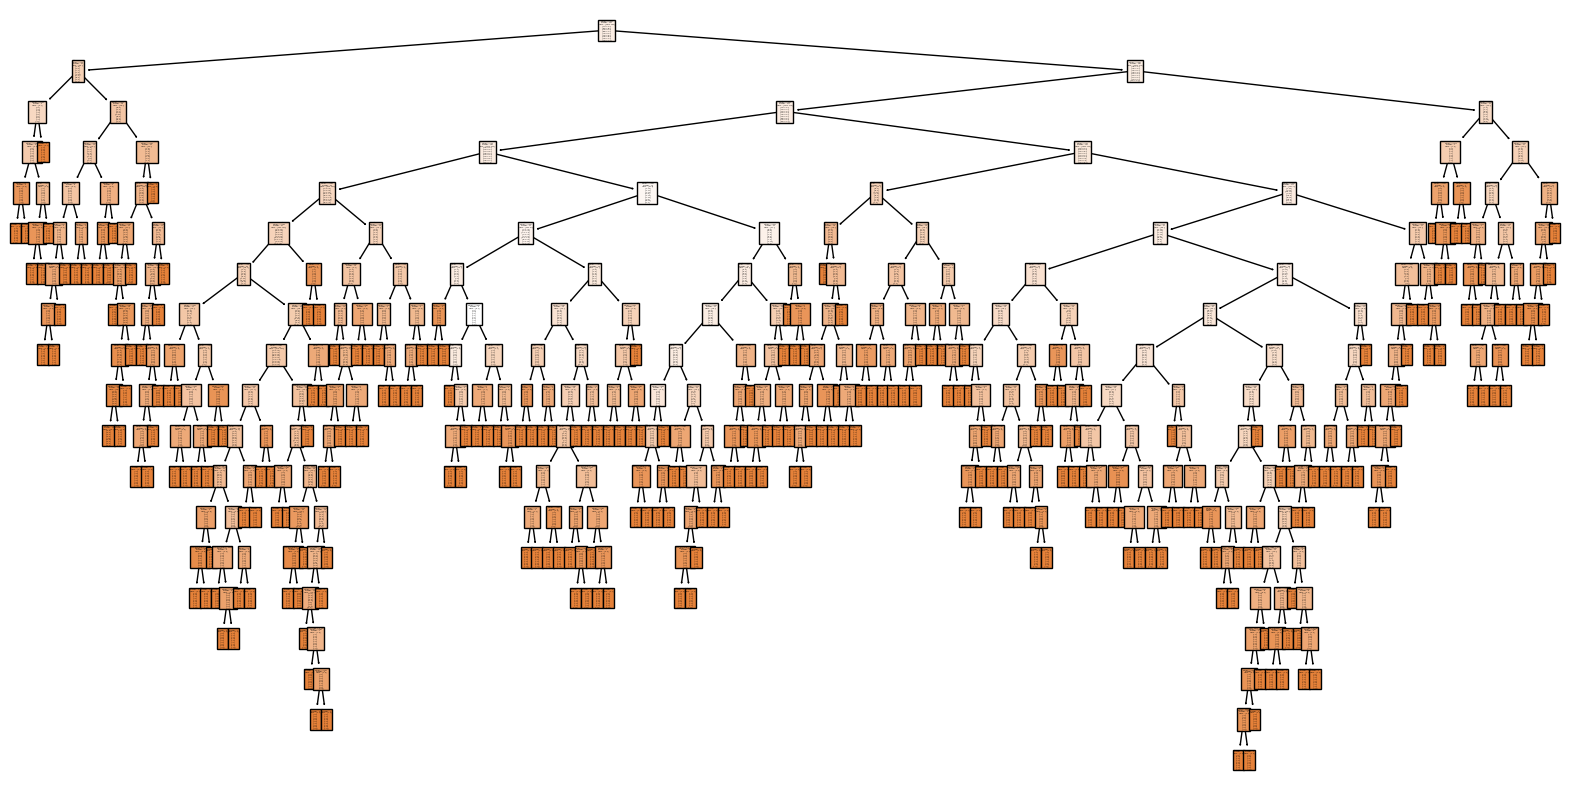

In [74]:
from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

plt.figure(figsize=(20, 10))
plot_tree(dt_classifier, feature_names=X_train.columns, class_names=dt_classifier.classes_, filled=True)
plt.show()
